# SHAP Global Validation & Feature Importance
## CVD Fairness Dissertation — NB1

**Purpose:** Validate the SHAP implementation, compute global feature importance for the full
test set, and produce sex-stratified explainability plots for clinical interpretation.

**Outputs saved to:** `outputs/shap/`

**This notebook:**
- Validates SHAP additivity and shape correctness
- Produces global summary plots (full test set)
- Produces sex-stratified summary and dependence plots
- Saves SHAP arrays for NB2 to load (no recomputation needed)

**Does NOT contain:** local explanations, waterfall plots, counterfactuals, fairness metrics
(those are in NB2 and fairness_evaluation.ipynb)

## 1. Imports

In [43]:
import pickle
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from pathlib import Path
from sklearn.inspection import PartialDependenceDisplay

## 2. Paths & Constants

In [44]:
# ── Paths ──────────────────────────────────────────────────────────────────
MODEL_PATH   = Path("../models/baseline_models/cardio_xgb_baseline_model.pkl")
TEST_DATA    = Path("../data/test_train_val_sets/cardio_baseline_test.csv")
CONFIG_PATH  = Path("../config/dataset_split_sizes.json")
OUTPUT_SHAP  = Path("../outputs/shap")
OUTPUT_SHAP.mkdir(parents=True, exist_ok=True)

# ── Constants ──────────────────────────────────────────────────────────────
THRESHOLD    = 0.5
GENDER_COL   = "gender"
FEMALE_VAL   = 0
MALE_VAL     = 1
DROP_COLS    = ["cardio", "stratify"]

EXPECTED_FEATURES = [
    "age_years", "gender", "height", "weight",
    "ap_hi", "ap_lo", "cholesterol", "gluc",
    "smoke", "alco", "active"
]

# Clinical reference thresholds (Ji et al.)
CLINICAL_REFS = {
    "ap_hi": [
        {"x": 110, "color": "red",    "label": "Female risk threshold (Ji et al.)"},
        {"x": 130, "color": "green",  "label": "Male risk threshold (Ji et al.)"},
    ],
    "age_years": [
        {"x": 52,  "color": "orange", "label": "Peri-menopausal transition (Ji et al.)"},
    ],
}

## 3. Notebook Sanity Checks

Validates that the correct model, test set, feature order, sex distribution, and class balance
are all consistent before any analysis runs. All checks raise `AssertionError` on failure so
the notebook halts immediately rather than silently producing wrong results.

In [45]:
# ── Load data & model ──────────────────────────────────────────────────────
with open(CONFIG_PATH) as f:
    expected_sizes = json.load(f)

test_df = pd.read_csv(TEST_DATA)
X_test  = test_df.drop(columns=DROP_COLS)
y_test  = test_df["cardio"]

with open(MODEL_PATH, "rb") as f:
    model = pickle.load(f)

# ── Check 1: Test set size ─────────────────────────────────────────────────
assert len(test_df) == expected_sizes["test"], (
    f"Test size mismatch: got {len(test_df)}, expected {expected_sizes['test']}"
)

# ── Check 2: Feature order matches model training ──────────────────────────
assert set(X_test.columns) == set(EXPECTED_FEATURES), (
    f"Feature set mismatch.\n  Got:      {sorted(X_test.columns.tolist())}\n  Expected: {sorted(EXPECTED_FEATURES)}"
)

# Also update the constant to match actual column order in your data
EXPECTED_FEATURES = list(X_test.columns)

# Check 3: Model loads and predicts without error 
test_preds = model.predict(X_test.iloc[:5])
assert len(test_preds) == 5, "Model prediction smoke test failed"

# Check 4: Sex distribution preserved from original split 
female_frac = (test_df[GENDER_COL] == FEMALE_VAL).mean()
assert 0.62 < female_frac < 0.68, (
    f"Sex distribution unexpected: {female_frac:.3f} female (expected ~0.65)"
)

# Check 5: Class balance preserved
cvd_frac = test_df["cardio"].mean()
assert 0.48 < cvd_frac < 0.52, (
    f"Class balance unexpected: {cvd_frac:.3f} CVD positive (expected ~0.50)"
)

# Check 6: No target leakage — cardio not in X_test 
assert "cardio" not in X_test.columns, "Target column 'cardio' found in X_test — data leakage"

# Check 7: Protected attribute present in feature matrix
assert GENDER_COL in X_test.columns, f"'{GENDER_COL}' missing from X_test"

# Check 8: No nulls in test set
null_counts = X_test.isnull().sum()
assert null_counts.sum() == 0, f"Nulls found in X_test:\n{null_counts[null_counts > 0]}"

# Summary 
y_pred = model.predict(X_test)

print("=" * 55)
print("  SANITY CHECKS — ALL PASSED ✓")
print("=" * 55)
print(f"  Test set size      : {len(test_df):,}")
print(f"  Features           : {X_test.shape[1]}")
print(f"  Female fraction    : {female_frac:.3f}")
print(f"  CVD fraction       : {cvd_frac:.3f}")
print(f"  Decision threshold : {THRESHOLD}")
print("=" * 55)

  SANITY CHECKS — ALL PASSED ✓
  Test set size      : 10,227
  Features           : 11
  Female fraction    : 0.650
  CVD fraction       : 0.495
  Decision threshold : 0.5


## 4. Build Sex Masks & Subgroup Splits

Sex masks are defined once here and reused throughout the notebook.
`gender == 0` = female, `gender == 1` = male — consistent with dataset coding.

In [46]:
female_mask = test_df[GENDER_COL].values == FEMALE_VAL #0
male_mask   = test_df[GENDER_COL].values == MALE_VAL #1

X_test_female = X_test[female_mask].copy()
X_test_male   = X_test[male_mask].copy()
y_test_female = y_test.values[female_mask]
y_test_male   = y_test.values[male_mask]

# ── Validation: masks are mutually exclusive and exhaustive 
assert (female_mask & male_mask).sum() == 0, \
    "Overlap between female and male masks"
assert (female_mask | male_mask).sum() == len(test_df), \
    "Masks do not cover full test set"
assert len(X_test_female) + len(X_test_male) == len(X_test), \
    "Subgroup sizes do not sum to test set size"

print(f"Female patients : {female_mask.sum():,}  ({female_mask.mean()*100:.1f}%)")
print(f"Male patients   : {male_mask.sum():,}  ({male_mask.mean()*100:.1f}%)")
print("Sex masks validated")

Female patients : 6,649  (65.0%)
Male patients   : 3,578  (35.0%)
Sex masks validated


## 5. SHAP Explainer Setup & Additivity Validation

`TreeExplainer` reads the XGBoost tree structure directly to compute **exact** Shapley values
rather than approximations. Validation confirms that for every patient, the sum of all SHAP
values plus the baseline exactly reconstructs the model's log-odds output.

A maximum deviation > 1×10⁻⁵ would indicate misconfiguration and halts the notebook.

In [47]:
# Build explainer
explainer = shap.TreeExplainer(model)

# Compute SHAP for full test set
# Using the Explanation object API (returns values + base_values + data)
sv_full = explainer(X_test)

print(f"SHAP array shape : {sv_full.values.shape}")
print(f"Expected shape   : {X_test.shape}")

SHAP array shape : (10227, 11)
Expected shape   : (10227, 11)


In [48]:
# ── Check 1: Shape validation ──────────────────────────────────────────────
assert sv_full.values.shape == X_test.shape, (
    f"SHAP shape mismatch: {sv_full.values.shape} vs expected {X_test.shape}"
)

# ── Check 2: Additivity validation ────────────────────────────────────────
# SHAP values are on log-odds scale for XGBoost classifiers
def _logit(p):
    return np.log(p / (1 - p))

pred_probs  = model.predict_proba(X_test)[:, 1]
pred_logits = _logit(pred_probs)

# For the Explanation object, base_values is per-sample (all identical)
shap_sums = sv_full.base_values + sv_full.values.sum(axis=1)
diffs     = np.abs(pred_logits - shap_sums)

ADDITIVITY_TOL = 1e-5
assert diffs.max() < ADDITIVITY_TOL, (
    f"Additivity check FAILED — max deviation {diffs.max():.2e} exceeds tolerance {ADDITIVITY_TOL:.0e}"
)
# max observed: 3.1e-6

print("=" * 50)
print("  SHAP VALIDATION — ALL PASSED")
print("=" * 50)
print(f"  Max deviation    : {diffs.max():.2e}  (tolerance {ADDITIVITY_TOL:.0e})")
print(f"  Mean deviation   : {diffs.mean():.2e}")
print(f"  Median deviation : {np.median(diffs):.2e}")
print(f"  SHAP shape       : {sv_full.values.shape}")
print("=" * 50)

  SHAP VALIDATION — ALL PASSED
  Max deviation    : 3.10e-06  (tolerance 1e-05)
  Mean deviation   : 4.61e-07
  Median deviation : 3.58e-07
  SHAP shape       : (10227, 11)


## 6. Sex-Stratified SHAP Computation

SHAP values are computed separately for female and male subgroups so that
feature importance and dependence patterns can be compared directly.
Both are also saved to `outputs/shap/` so NB2 can load them without recomputing.

In [49]:
sv_female = explainer(X_test_female)
sv_male   = explainer(X_test_male)

# ── Validation: subgroup SHAP shapes ──────────────────────────────────────
assert sv_female.values.shape == X_test_female.shape, \
    f"Female SHAP shape mismatch: {sv_female.values.shape}"
assert sv_male.values.shape == X_test_male.shape, \
    f"Male SHAP shape mismatch: {sv_male.values.shape}"
assert sv_female.values.shape[0] + sv_male.values.shape[0] == len(X_test), \
    "Subgroup SHAP row counts do not sum to full test set"

print(f"Female SHAP shape : {sv_female.values.shape}")
print(f"Male SHAP shape   : {sv_male.values.shape}")

Female SHAP shape : (6649, 11)
Male SHAP shape   : (3578, 11)


In [50]:
# ── Save SHAP arrays for NB2 
np.save(OUTPUT_SHAP / "shap_values_baseline_full.npy",   sv_full.values)
np.save(OUTPUT_SHAP / "shap_values_baseline_female.npy", sv_female.values)
np.save(OUTPUT_SHAP / "shap_values_baseline_male.npy",   sv_male.values)

# Save base value (scalar — same for all patients)
np.save(OUTPUT_SHAP / "shap_base_value.npy", np.array([sv_full.base_values[0]]))

print(f"Saved to {OUTPUT_SHAP}/")
print(f"  shap_values_baseline_full.npy    {sv_full.values.shape}")
print(f"  shap_values_baseline_female.npy  {sv_female.values.shape}")
print(f"  shap_values_baseline_male.npy    {sv_male.values.shape}")
print(f"  shap_base_value.npy              scalar")



Saved to ..\outputs\shap/
  shap_values_baseline_full.npy    (10227, 11)
  shap_values_baseline_female.npy  (6649, 11)
  shap_values_baseline_male.npy    (3578, 11)
  shap_base_value.npy              scalar


In [51]:
rows = {}
for label, sv, X in [
    ("Overall", sv_full,   X_test),
    ("Female",  sv_female, X_test_female),
    ("Male",    sv_male,   X_test_male),
]:
    mean_shap = pd.Series(
        np.abs(sv.values).mean(axis=0),
        index=X.columns
    ).sort_values(ascending=False).head(5)
    rows[label] = mean_shap

# union of all top-5 features
all_features = pd.Index(
    list(rows["Overall"].index) +
    list(rows["Female"].index)  +
    list(rows["Male"].index)
).unique()

df_shap = pd.DataFrame({
    "Feature":          all_features,
    "Mean SHAP Overall": [rows["Overall"].get(f, None) for f in all_features],
    "Mean SHAP Female":  [rows["Female"].get(f,  None) for f in all_features],
    "Mean SHAP Male":    [rows["Male"].get(f,    None) for f in all_features],
}).round(4)
for col in ["Mean SHAP Overall", "Mean SHAP Female", "Mean SHAP Male"]:
    df_shap[col] = df_shap[col].apply(lambda x: f"{x:.4f}" if pd.notna(x) else "")

# ── Excel output ──────────────────────────────────────────
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

HEADER_FILL = PatternFill("solid", start_color="1F4E79")
ALT_FILL    = PatternFill("solid", start_color="D6E4F0")
WHITE_FILL  = PatternFill("solid", start_color="FFFFFF")
HEADER_FONT = Font(name="Arial", bold=True, color="FFFFFF", size=10)
BODY_FONT   = Font(name="Arial", size=10)
CENTER      = Alignment(horizontal="center", vertical="center")
LEFT        = Alignment(horizontal="left",   vertical="center")
THIN        = Side(style="thin", color="B0C4DE")
BORDER      = Border(left=THIN, right=THIN, top=THIN, bottom=THIN)

wb = Workbook()
ws = wb.active
ws.title = "Top5 SHAP"

ws.merge_cells(start_row=1, start_column=1, end_row=1, end_column=4)
tc = ws.cell(row=1, column=1, value="Top 5 Features by Mean |SHAP|")
tc.font      = Font(name="Arial", bold=True, size=12, color="FFFFFF")
tc.fill      = PatternFill("solid", start_color="0D2D4E")
tc.alignment = CENTER

for col_idx, col_name in enumerate(df_shap.columns, start=1):
    cell = ws.cell(row=2, column=col_idx, value=col_name)
    cell.font = HEADER_FONT; cell.fill = HEADER_FILL
    cell.alignment = CENTER; cell.border = BORDER

for row_idx, row in enumerate(df_shap.itertuples(index=False), start=3):
    fill = ALT_FILL if row_idx % 2 == 0 else WHITE_FILL
    for col_idx, value in enumerate(row, start=1):
        cell = ws.cell(row=row_idx, column=col_idx, value=value)
        cell.font = BODY_FONT; cell.fill = fill; cell.border = BORDER
        cell.alignment = LEFT if col_idx == 1 else CENTER

for col_idx, width in enumerate([16, 18, 18, 18], start=1):
    ws.column_dimensions[get_column_letter(col_idx)].width = width

wb.save(OUTPUT_SHAP / "shap_top5_features.xlsx")
print("Saved → shap_top5_features.xlsx")

PermissionError: [Errno 13] Permission denied: '..\\outputs\\shap\\shap_top5_features.xlsx'

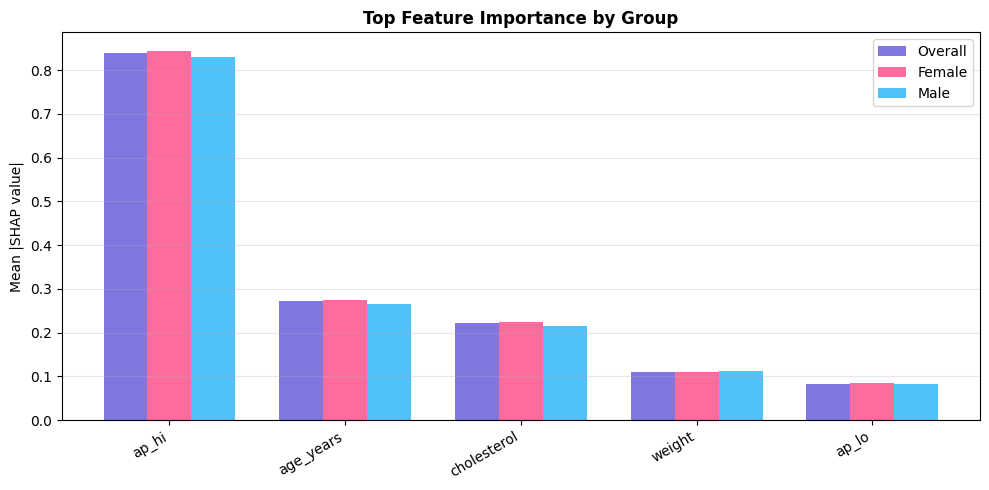

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

all_features = list(rows["Overall"].index)
for label in ["Female", "Male"]:
    for f in rows[label].index:
        if f not in all_features:
            all_features.append(f)

x     = np.arange(len(all_features))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, [rows["Overall"].get(f, 0) for f in all_features], width, label="Overall", color="#7F77DD")
ax.bar(x,         [rows["Female"].get(f, 0)  for f in all_features], width, label="Female",  color="#ff6b9d")
ax.bar(x + width, [rows["Male"].get(f, 0)    for f in all_features], width, label="Male",    color="#4fc3f7")

ax.set_xticks(x)
ax.set_xticklabels(all_features, rotation=30, ha="right")
ax.set_ylabel("Mean |SHAP value|")
ax.set_title("Top Feature Importance by Group", fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_SHAP / "shap_top5_grouped_bar.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Global Summary Plots — Full Test Set

The beeswarm (dot) plot shows each patient as a point: position on the x-axis is the SHAP value
(positive = pushes toward CVD), colour is the feature value (red = high, blue = low).
The bar plot shows mean absolute SHAP — overall feature importance ranking.

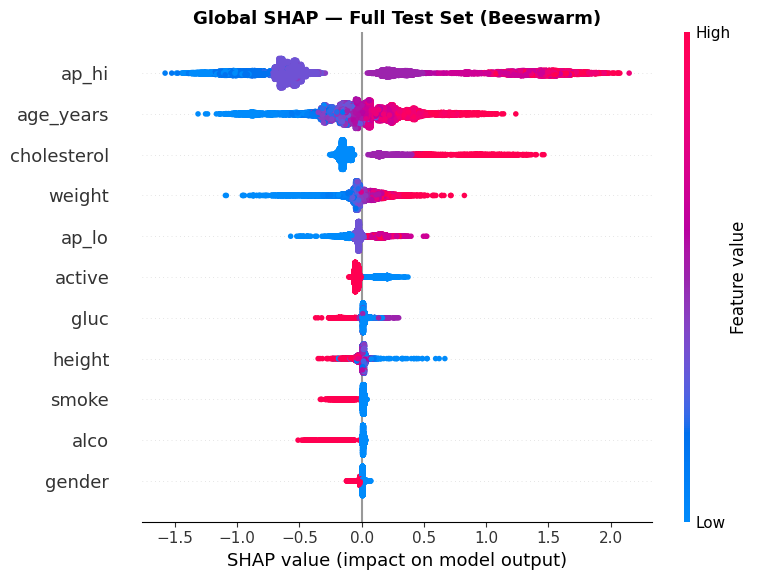

Saved: shap_summary_dot_full.png


In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
shap.summary_plot(sv_full.values, X_test, plot_type="dot", show=False)
plt.title("Global SHAP — Full Test Set (Beeswarm)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_SHAP / "shap_summary_dot_full.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: shap_summary_dot_full.png")

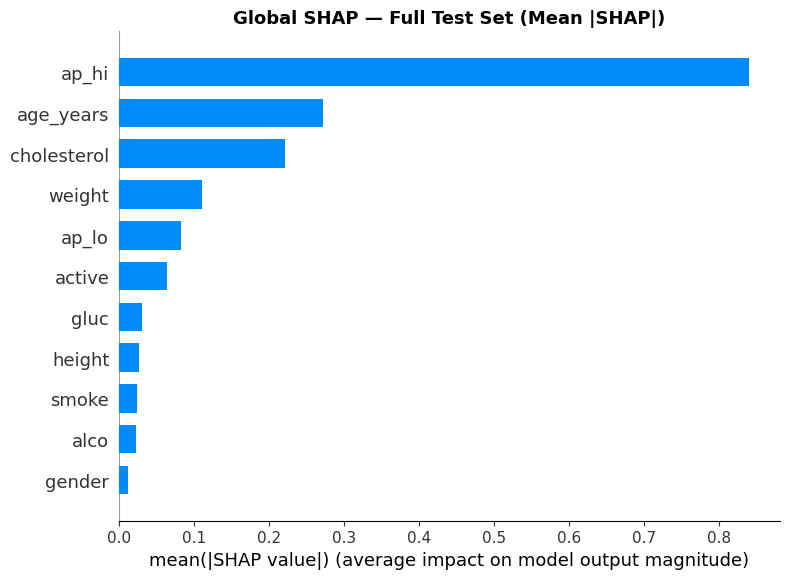

Saved: shap_summary_bar_full.png


In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
shap.summary_plot(sv_full.values, X_test, plot_type="bar", show=False)
plt.title("Global SHAP — Full Test Set (Mean |SHAP|)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_SHAP / "shap_summary_bar_full.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: shap_summary_bar_full.png")

## 8. Sex-Stratified Summary Plots

The same summary plots repeated separately for female and male patients.
Side-by-side comparison reveals whether the model's feature ranking
and direction of effect differ by sex.

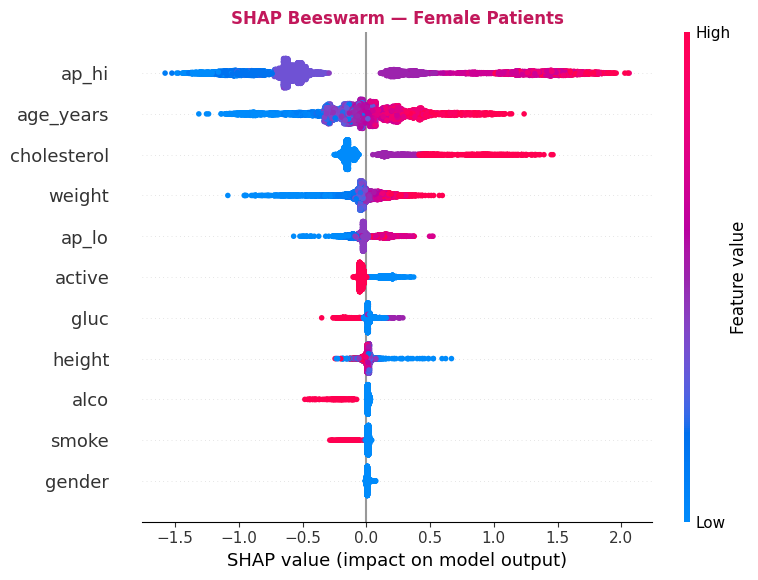

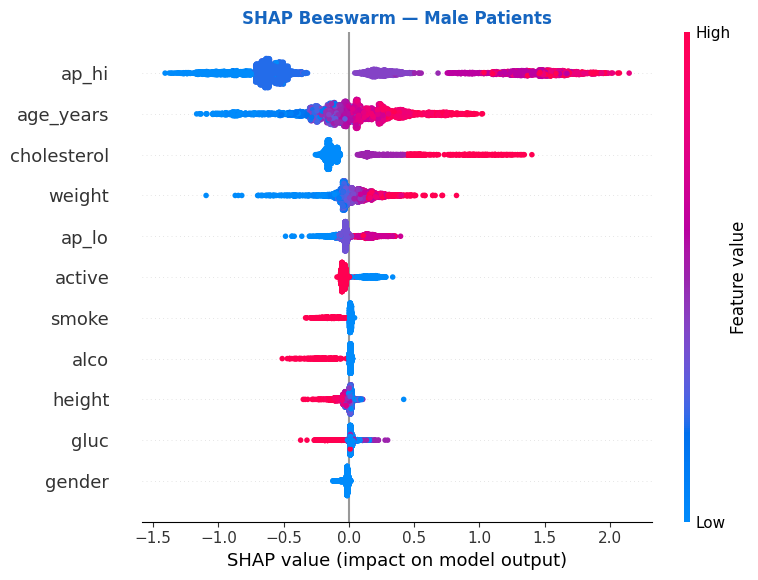

In [ ]:
# ── Dot plots side by side ─────────────────────────────────────────────────
for title, sv, X, color, fname in [
    ("SHAP Beeswarm — Female Patients", sv_female, X_test_female, "#c2185b", "shap_summary_dot_female.png"),
    ("SHAP Beeswarm — Male Patients",   sv_male,   X_test_male,   "#1565c0", "shap_summary_dot_male.png"),
]:
    fig, ax = plt.subplots(figsize=(6, 7))
    plt.sca(ax)
    shap.summary_plot(sv.values, X, plot_type="dot", show=False)
    ax.set_title(title, fontsize=12, fontweight="bold", color=color)
    plt.tight_layout()
    plt.savefig(OUTPUT_SHAP / fname, dpi=150, bbox_inches="tight")
    plt.show()

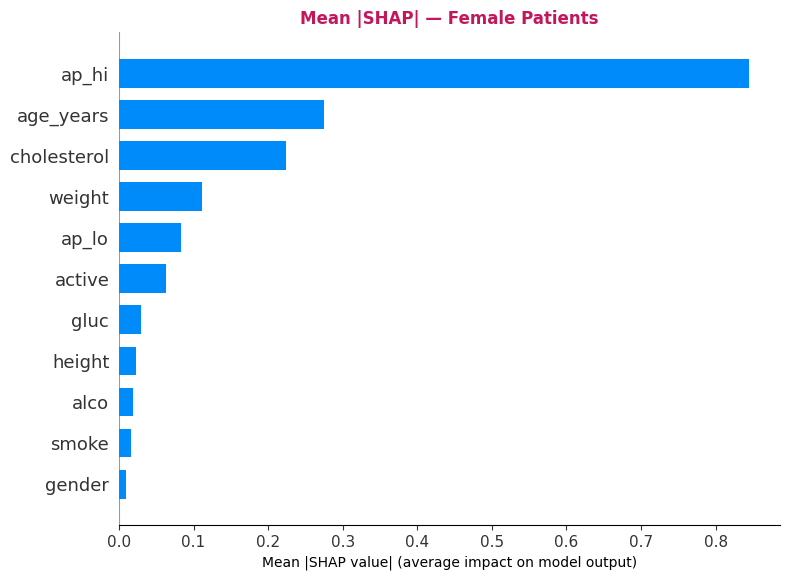

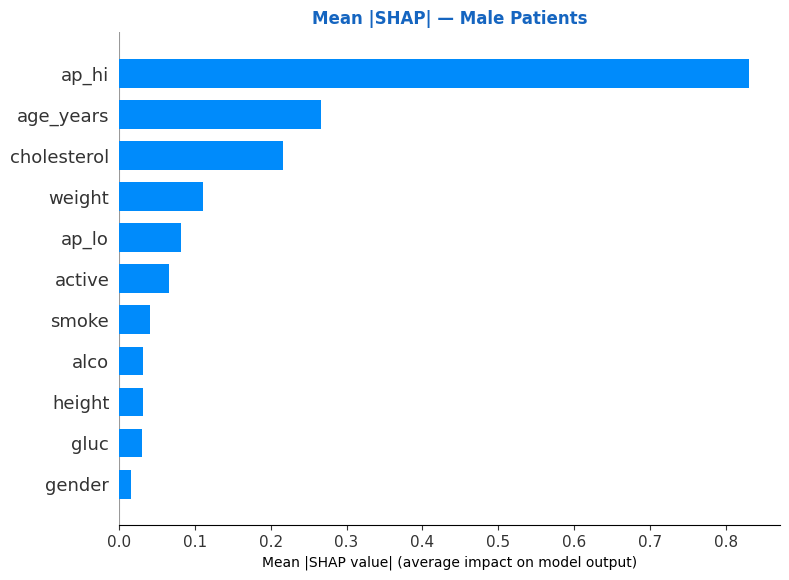

In [ ]:
for title, sv, X, color, fname in [
    ("Mean |SHAP| — Female Patients", sv_female, X_test_female, "#c2185b", "shap_summary_bar_female.png"),
    ("Mean |SHAP| — Male Patients",   sv_male,   X_test_male,   "#1565c0", "shap_summary_bar_male.png"),
]:
    fig, ax = plt.subplots(figsize=(7, 5))
    plt.sca(ax)
    shap.summary_plot(sv.values, X, plot_type="bar", show=False)
    ax.set_title(title, fontsize=12, fontweight="bold", color=color)
    ax.set_xlabel("Mean |SHAP value| (average impact on model output)", fontsize=10)
    plt.tight_layout()
    plt.savefig(OUTPUT_SHAP / fname, dpi=150, bbox_inches="tight")
    plt.show()

## 9. SHAP Dependence Plots — 6 Features, Sex-Stratified

For each feature, the dependence plot shows the SHAP value for every patient
against that feature's value. Side-by-side female/male panels reveal whether
the model responds to the same feature values differently by sex.

`ap_hi` is the clinically critical feature — its panel is also saved separately
as the primary figure for clinical benchmarking in Chapter 4.

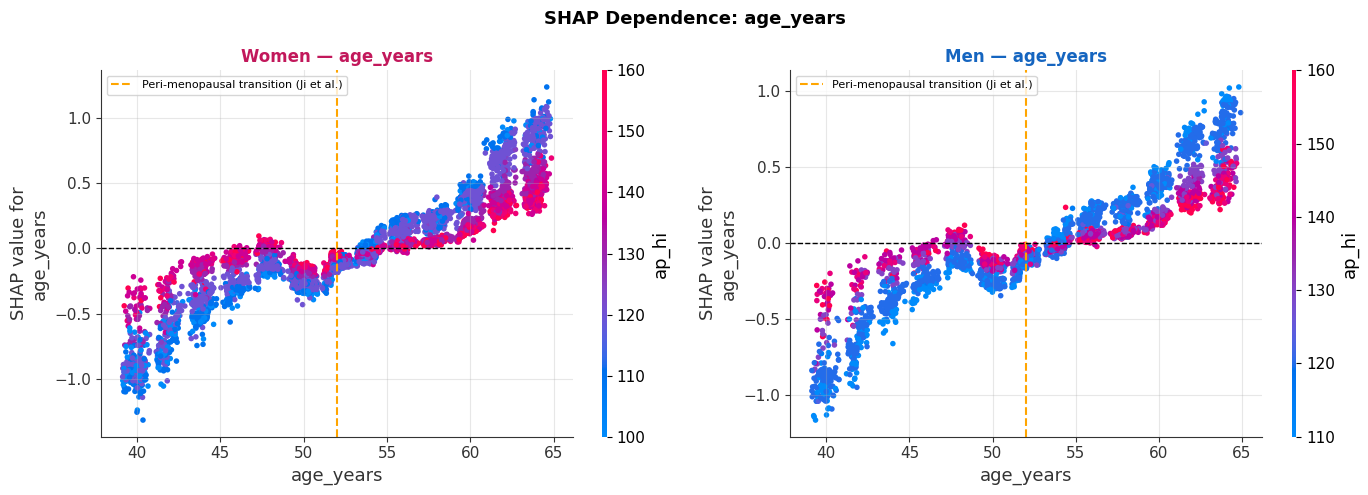

Saved: shap_dependence_age_years_sex_stratified.png


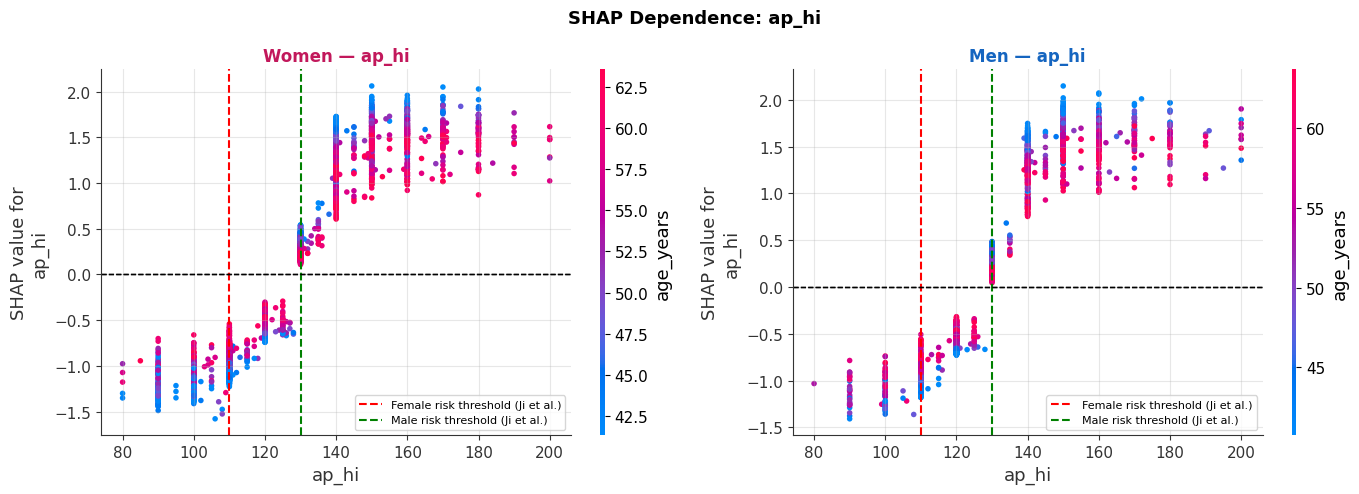

Saved: shap_dependence_ap_hi_sex_stratified.png


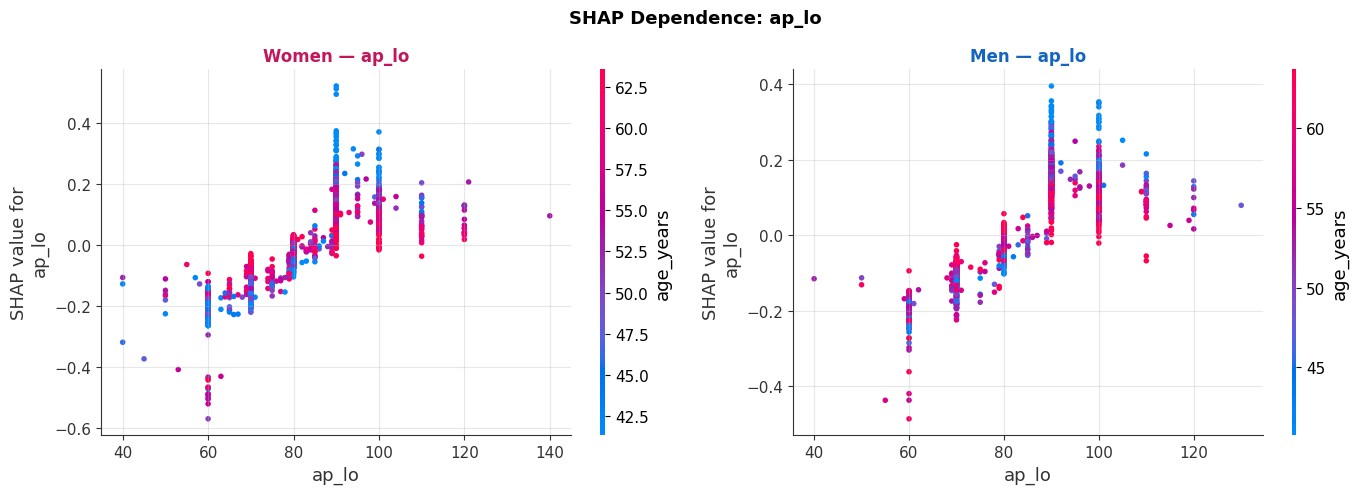

Saved: shap_dependence_ap_lo_sex_stratified.png


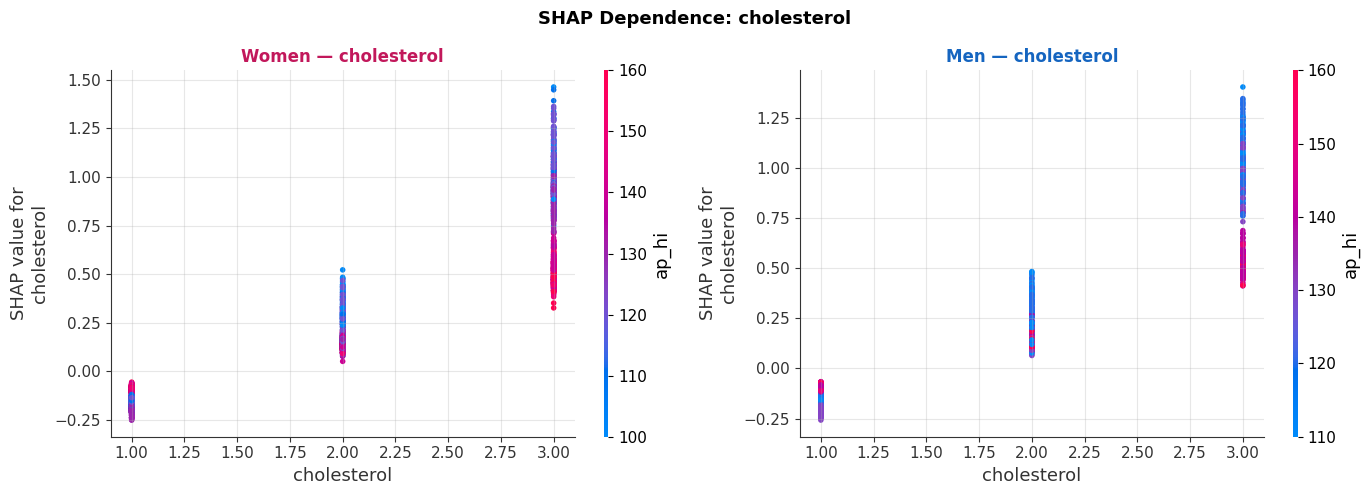

Saved: shap_dependence_cholesterol_sex_stratified.png


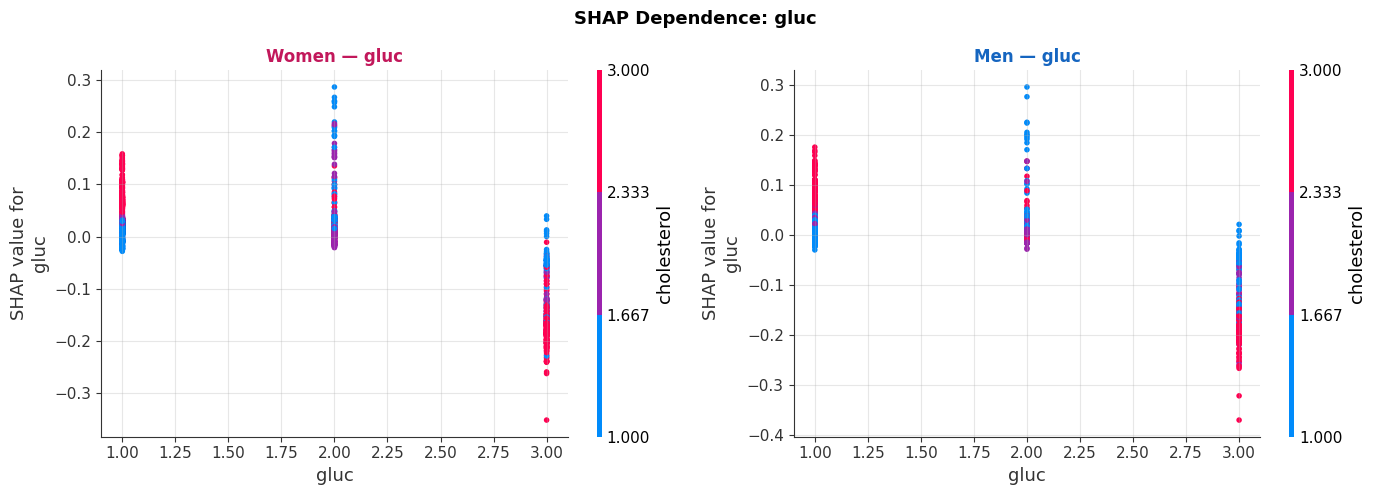

Saved: shap_dependence_gluc_sex_stratified.png


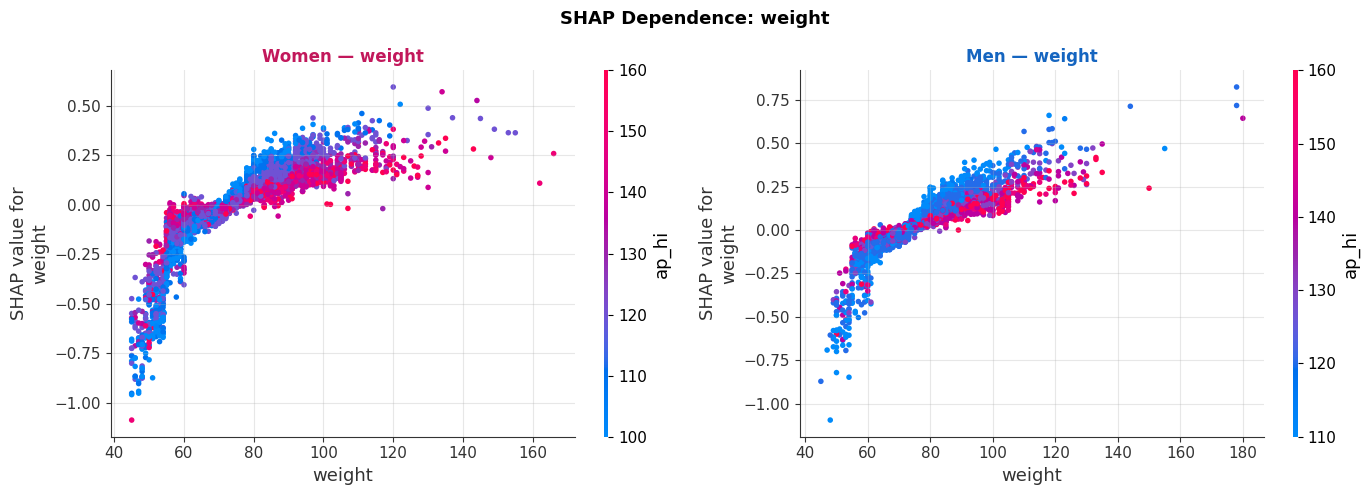

Saved: shap_dependence_weight_sex_stratified.png


In [65]:
DEPENDENCE_FEATURES = ["age_years", "ap_hi", "ap_lo", "cholesterol", "gluc", "weight"]

for feat in DEPENDENCE_FEATURES:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    shap.dependence_plot(feat, sv_female.values, X_test_female,
                         ax=axes[0], show=False)
    axes[0].set_title(f"Women — {feat}", fontweight="bold", color="#c2185b")
    axes[0].grid(alpha=0.3)

    shap.dependence_plot(feat, sv_male.values, X_test_male,
                         ax=axes[1], show=False)
    axes[1].set_title(f"Men — {feat}", fontweight="bold", color="#1565c0")
    axes[1].grid(alpha=0.3)

    # Add clinical reference lines where defined
    if feat in CLINICAL_REFS:
        for ref in CLINICAL_REFS[feat]:
            for ax in axes:
                ax.axvline(x=ref["x"], color=ref["color"], linestyle="--",
                           linewidth=1.5, label=ref["label"])
                ax.axhline(y=0, color="black", linestyle="--", linewidth=1)
                ax.legend(fontsize=8)

    plt.suptitle(f"SHAP Dependence: {feat}", fontsize=13, fontweight="bold")
    plt.tight_layout()

    fname = f"shap_dependence_{feat}_sex_stratified.png"
    plt.savefig(OUTPUT_SHAP / fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")

## 10. `ap_hi` Interaction-Coloured Dependence

For women: `ap_hi` SHAP values coloured by `age_years` — tests whether
peri-menopausal women (≥52) show different model response to the same blood pressure.

For men: coloured by `cholesterol` — tests for combined metabolic risk pattern.

Clinical reference lines from Ji et al.: female threshold 110 mmHg, male threshold 130 mmHg.

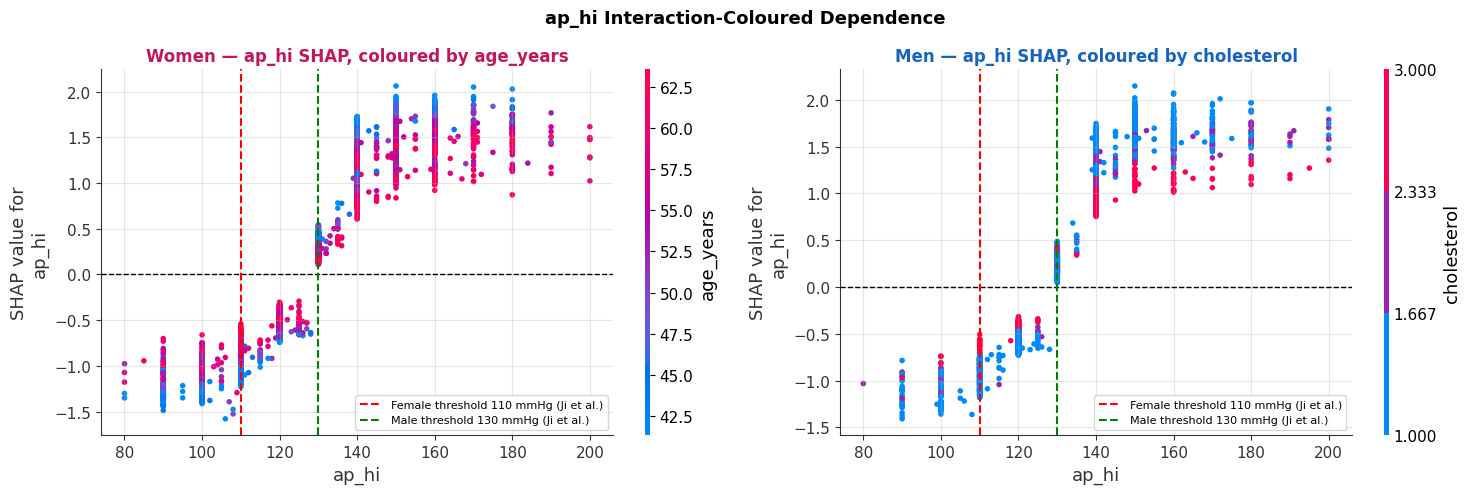

Saved: shap_dependence_ap_hi_interaction.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Women — ap_hi coloured by age
shap.dependence_plot("ap_hi", sv_female.values, X_test_female,
                     interaction_index="age_years", ax=axes[0], show=False)
axes[0].set_title("Women — ap_hi SHAP, coloured by age_years",
                  fontweight="bold", color="#c2185b")
axes[0].axhline(y=0,   color="black", linestyle="--", linewidth=1)
axes[0].axvline(x=110, color="red",   linestyle="--", linewidth=1.5,
                label="Female threshold 110 mmHg (Ji et al.)")
axes[0].axvline(x=130, color="green", linestyle="--", linewidth=1.5,
                label="Male threshold 130 mmHg (Ji et al.)")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# Men — ap_hi coloured by cholesterol
shap.dependence_plot("ap_hi", sv_male.values, X_test_male,
                     interaction_index="cholesterol", ax=axes[1], show=False)
axes[1].set_title("Men — ap_hi SHAP, coloured by cholesterol",
                  fontweight="bold", color="#1565c0")
axes[1].axhline(y=0,   color="black", linestyle="--", linewidth=1)
axes[1].axvline(x=110, color="red",   linestyle="--", linewidth=1.5,
                label="Female threshold 110 mmHg (Ji et al.)")
axes[1].axvline(x=130, color="green", linestyle="--", linewidth=1.5,
                label="Male threshold 130 mmHg (Ji et al.)")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.suptitle("ap_hi Interaction-Coloured Dependence", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_SHAP / "shap_dependence_ap_hi_interaction.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: shap_dependence_ap_hi_interaction.png")

## 11. Partial Dependence Plots — `ap_hi` and `age_years`

PDPs show the **average** model prediction as a function of a single feature,
marginalising over all other features. Complements SHAP dependence by showing
the overall response curve rather than individual patient contributions.

Clinical reference lines mark sex-specific risk thresholds from Ji et al.

c:\Users\kavis\OneDrive\Desktop\Study Resources\Year 3\Diss\Code\Dissertation_ExplainableAI\.venv\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 3 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
c:\Users\kavis\OneDrive\Desktop\Study Resources\Year 3\Diss\Code\Dissertation_ExplainableAI\.venv\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 3 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will r

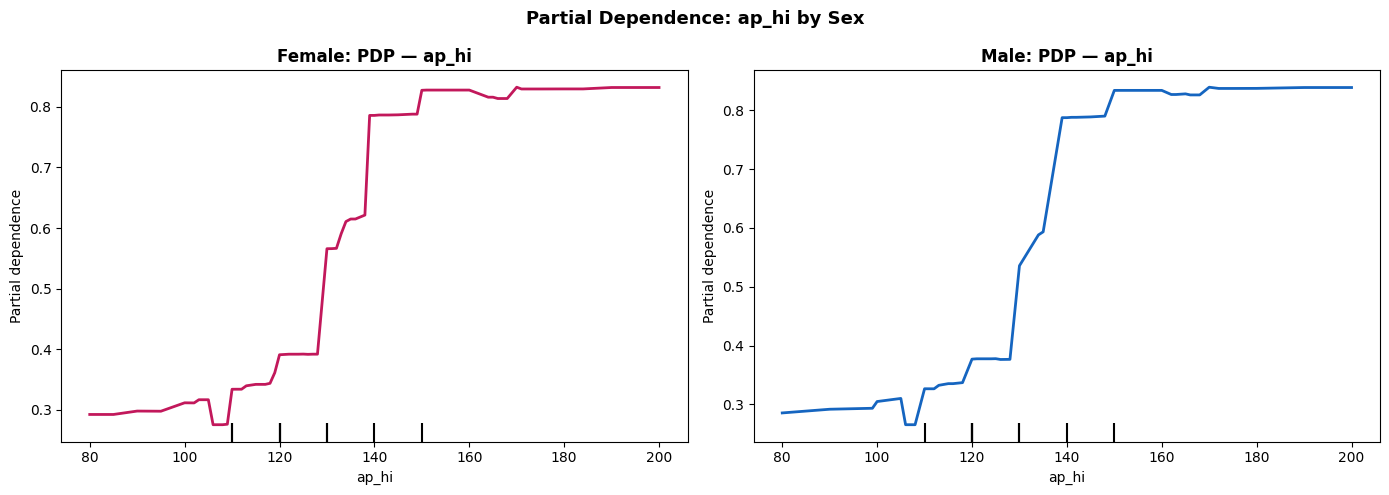

Saved: pdp_ap_hi_sex_stratified.png


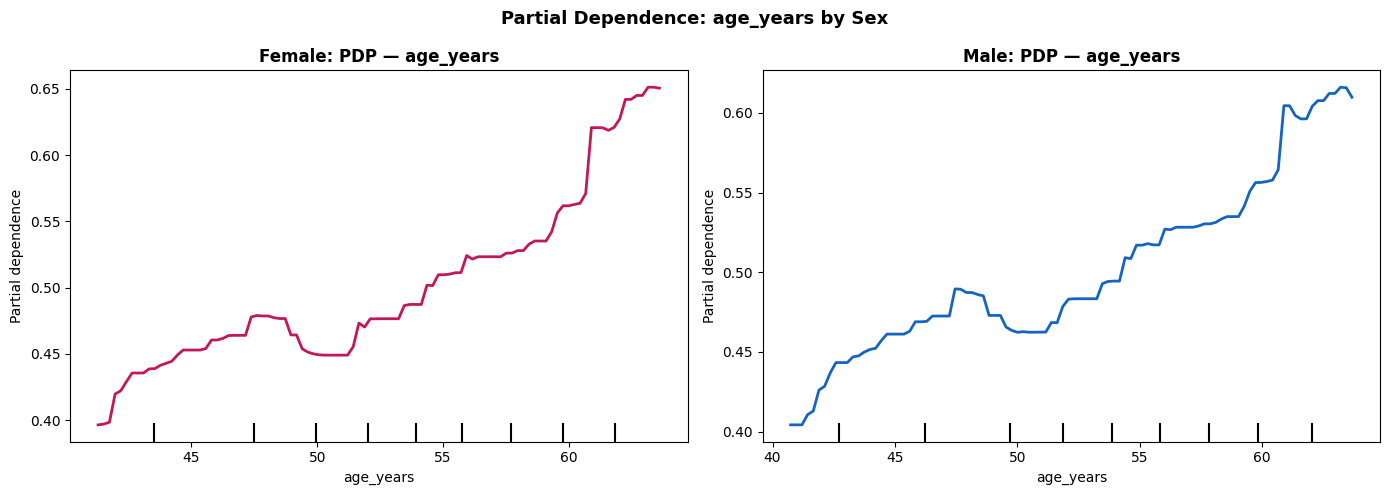

Saved: pdp_age_years_sex_stratified.png


In [ ]:
PDP_FEATURES = ["ap_hi", "age_years"]

for feature in PDP_FEATURES:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, X_data, color, label in [
        (axes[0], X_test_female, "#c2185b", "Female"),
        (axes[1], X_test_male,   "#1565c0", "Male"),
    ]:
        PartialDependenceDisplay.from_estimator(
            model, X_data, features=[feature],
            ax=ax, line_kw={"color": color, "linewidth": 2}
        )
        if feature in CLINICAL_REFS:
            for ref in CLINICAL_REFS[feature]:
                ax.axvline(x=ref["x"], color=ref["color"], linestyle="--",
                           linewidth=1.5, label=ref["label"])
            ax.legend(fontsize=8)

        ax.set_title(f"{label}: PDP — {feature}", fontweight="bold")
        ax.grid(alpha=0.3)

    plt.suptitle(f"Partial Dependence: {feature} by Sex", fontsize=13, fontweight="bold")
    plt.tight_layout()
    fname = f"pdp_{feature}_sex_stratified.png"
    plt.savefig(OUTPUT_SHAP / fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")

## 12. SHAP Response to Systolic BP by Bin — Female Patients

Systolic BP is divided into clinically meaningful ranges and the mean SHAP
response per bin is computed for female patients.

This shows whether the model under-weights blood pressure risk for women
in the 120-129 mmHg range, which sits between the female clinical risk
threshold (110 mmHg, Ji et al.) and the model's effective learned threshold
of around 130 mmHg.

In [ ]:
BP_BINS        = [0, 120, 130, 140, 150, 160, np.inf]
BP_BIN_LABELS  = ["<120", "120-129", "130-139", "140-149", "150-159", "160+"]
HIGH_RISK_BINS = ["140-149", "150-159", "160+"]
FEAT           = "ap_hi"
FEAT_IDX       = list(X_test.columns).index(FEAT)

# Build female analysis DataFrame — reset index for alignment
df_flag = X_test_female.copy().reset_index(drop=True)
df_flag["shap_value"] = sv_female.values[:, FEAT_IDX].astype(float)

df_flag["feature_bin"] = pd.cut(
    df_flag[FEAT], bins=BP_BINS, labels=BP_BIN_LABELS, right=False
)

# 10th percentile threshold per bin
bin_thresholds = (
    df_flag.groupby("feature_bin", observed=True)["shap_value"]
    .quantile(0.10).astype(float).to_dict()
)
df_flag["bin_threshold"] = df_flag["feature_bin"].astype(str).map(bin_thresholds)

# Underresponse flags
df_flag["underresponse_flag"] = (
    df_flag["shap_value"] <= df_flag["bin_threshold"]
).astype(int)

df_flag["underresponse_flag_highrisk"] = (
    df_flag["feature_bin"].isin(HIGH_RISK_BINS) &
    (df_flag["shap_value"] <= df_flag["bin_threshold"])
).astype(int)

# Align true labels and predictions to reset index
y_pred_female = model.predict(X_test_female)
df_flag["true_label"] = y_test_female
df_flag["predicted"]  = y_pred_female
df_flag["is_fn"]      = ((df_flag["true_label"] == 1) & (df_flag["predicted"] == 0)).astype(int)

# ── Validation ─────────────────────────────────────────────────────────────
assert df_flag["underresponse_flag"].isnull().sum() == 0, \
    "Null values in underresponse_flag — bin threshold mapping failed"
assert len(df_flag) == female_mask.sum(), \
    "Flag DataFrame row count does not match female subgroup size"

print("Underresponse flag DataFrame validated (female)")

✓ Underresponse flag DataFrame validated


In [ ]:
df_flag_male = X_test_male.copy().reset_index(drop=True)
df_flag_male["shap_value"] = sv_male.values[:, FEAT_IDX].astype(float)

df_flag_male["feature_bin"] = pd.cut(
    df_flag_male[FEAT], bins=BP_BINS, labels=BP_BIN_LABELS, right=False
)

bin_thresholds_male = (
    df_flag_male.groupby("feature_bin", observed=True)["shap_value"]
    .quantile(0.10).astype(float).to_dict()
)
df_flag_male["bin_threshold"] = df_flag_male["feature_bin"].astype(str).map(bin_thresholds_male)

df_flag_male["underresponse_flag"] = (
    df_flag_male["shap_value"] <= df_flag_male["bin_threshold"]
).astype(int)

df_flag_male["underresponse_flag_highrisk"] = (
    df_flag_male["feature_bin"].isin(HIGH_RISK_BINS) &
    (df_flag_male["shap_value"] <= df_flag_male["bin_threshold"])
).astype(int)

y_pred_male = model.predict(X_test_male)
df_flag_male["true_label"] = y_test_male
df_flag_male["predicted"]  = y_pred_male
df_flag_male["is_fn"]      = ((df_flag_male["true_label"] == 1) & (df_flag_male["predicted"] == 0)).astype(int)

# ── Validation ────────────────────────────────────────────
assert df_flag_male["underresponse_flag"].isnull().sum() == 0, \
    "Null values in underresponse_flag — bin threshold mapping failed"
assert len(df_flag_male) == male_mask.sum(), \
    "Flag DataFrame row count does not match male subgroup size"

print("Underresponse flag DataFrame validated (male)")

✓ Underresponse flag DataFrame validated (male)


In [59]:
for sex, df, fname in [
    ("Female", df_flag,      "fn_rate_by_bp_bin_female.csv"),
    ("Male",   df_flag_male, "fn_rate_by_bp_bin_male.csv"),
]:
    print(f"\nFN rate by BP bin — {sex} patients")
    print(f"{'Bin':<12} {'FN rate':>10} {'N patients':>12}")
    print("-" * 37)

    rows = []
    for bl in BP_BIN_LABELS:
        bin_df  = df[df["feature_bin"] == bl]
        fn_rate = bin_df["is_fn"].mean()
        n       = len(bin_df)
        print(f"{bl:<12} {fn_rate:>10.3f} {n:>12}")
        rows.append({"bin": bl, "fn_rate": fn_rate, "n_patients": n})

    pd.DataFrame(rows).to_csv(OUTPUT_SHAP / fname, index=False)


FN rate by BP bin — Female patients
Bin             FN rate   N patients
-------------------------------------
<120              0.186         1369
120-129           0.259         2603
130-139           0.089          881
140-149           0.001          947
150-159           0.000          410
160+              0.000          439

FN rate by BP bin — Male patients
Bin             FN rate   N patients
-------------------------------------
<120              0.222          486
120-129           0.270         1587
130-139           0.108          493
140-149           0.000          507
150-159           0.000          241
160+              0.000          264


## 13. SHAP Response by BP and Age Bin — Female vs Male

Compares the mean SHAP response per bin between female and male patients
for systolic BP and age. Shows whether the model weights the same BP range
or age group differently depending on sex, and whether that lines up with
the sex-specific risk patterns described by Ji et al.

In [55]:
AGE_BINS   = [0, 40, 45, 50, 55, 60, np.inf]
AGE_LABELS = ["<40", "40-44", "45-49", "50-54", "55-59", "60+"]

def _bin_shap_summary(X_sub, shap_vals, feature, bins, labels):
    feat_idx = list(X_test.columns).index(feature)
    df_b = X_sub.copy().reset_index(drop=True)
    df_b["shap_value"] = shap_vals[:, feat_idx].astype(float)
    df_b["feature_bin"] = pd.cut(df_b[feature], bins=bins, labels=labels, right=False)
    return df_b.groupby("feature_bin", observed=True)["shap_value"].agg(["mean", "median", "count"])

female_aphi = _bin_shap_summary(X_test_female, sv_female.values, "ap_hi", BP_BINS, BP_BIN_LABELS)
male_aphi   = _bin_shap_summary(X_test_male,   sv_male.values,   "ap_hi", BP_BINS, BP_BIN_LABELS)

female_age  = _bin_shap_summary(X_test_female, sv_female.values, "age_years", AGE_BINS, AGE_LABELS)
male_age    = _bin_shap_summary(X_test_male,   sv_male.values,   "age_years", AGE_BINS, AGE_LABELS)

thresh_aphi = pd.DataFrame({
    "female_mean_shap": female_aphi["mean"],
    "male_mean_shap":   male_aphi["mean"],
    "female_median_shap": female_aphi["median"],
    "male_median_shap":   male_aphi["median"],
}).round(4)

thresh_age = pd.DataFrame({
    "female_mean_shap": female_age["mean"],
    "male_mean_shap":   male_age["mean"],
    "female_median_shap": female_age["median"],
    "male_median_shap":   male_age["median"],
}).round(4)

print("ap_hi — mean SHAP per bin, female vs male")
print(thresh_aphi.to_string())
print("\nage_years — mean SHAP per bin, female vs male")
print(thresh_age.to_string())

thresh_aphi.to_csv(OUTPUT_SHAP / "shap_bin_summary_ap_hi.csv")
thresh_age.to_csv(OUTPUT_SHAP / "shap_bin_summary_age_years.csv")

ap_hi — mean SHAP per bin, female vs male
             female_mean_shap  male_mean_shap  female_median_shap  male_median_shap
feature_bin                                                                        
<120                  -1.0155         -0.9542             -1.0074           -0.9447
120-129               -0.5740         -0.5846             -0.5804           -0.5950
130-139                0.2918          0.2605              0.2691            0.2468
140-149                1.2486          1.2899              1.2817            1.3136
150-159                1.5226          1.5800              1.5468            1.5891
160+                   1.5146          1.5703              1.5446            1.5832

age_years — mean SHAP per bin, female vs male
             female_mean_shap  male_mean_shap  female_median_shap  male_median_shap
feature_bin                                                                        
<40                   -0.8437         -0.8141             -0.8958      

In [71]:
MODEL_REFINED_PATH = Path("../models/refined_models")
# Load feature-engineered test set
X_test_fe = pd.read_csv("../data/test_train_val_sets/cardio_fe_test.csv")
X_test_fe = X_test_fe.drop(columns=[c for c in DROP_COLS if c in X_test_fe.columns])

def load(path):
    with open(path, 'rb') as f:
        return pickle.load(f)

models = {
    "Monotone":    (load(MODEL_REFINED_PATH / "cardio_xgb_monotone.pkl"),       X_test),
    "Weighted":    (load(MODEL_REFINED_PATH / "cardio_xgb_weighted.pkl"),       X_test),
    "Constrained": (load(MODEL_REFINED_PATH / "cardio_xgb_constrained.pkl"),    X_test),
    "FE":          (load(MODEL_REFINED_PATH / "cardio_xgb_fe.pkl"),             X_test_fe),
}

bins = [0, 120, 130, 140, 150, 160, 300]
bin_labels = ['<120', '120-129', '130-139', '140-149', '150-159', '160+']

female_rows = []
male_rows = []

for model_name, (m, X) in models.items():
    y_pred_all = m.predict(X)
    
    for sex, mask_val, label, rows_list in [
        ("Female", FEMALE_VAL, "female", female_rows),
        ("Male",   MALE_VAL,   "male",   male_rows)
    ]:
        sex_mask = test_df[GENDER_COL].values == mask_val
        
        y_pred_s = y_pred_all[sex_mask]
        y_true_s = y_test.values[sex_mask]
        ap_hi_s = X[sex_mask]['ap_hi'].values
        
        df_flag = pd.DataFrame({
            'ap_hi': ap_hi_s,
            'is_fn': ((y_true_s == 1) & (y_pred_s == 0)).astype(int),
            'feature_bin': pd.cut(ap_hi_s, bins=BP_BINS,
                                  labels=BP_BIN_LABELS, right=False)
        })
        
        for bl in BP_BIN_LABELS:
            bin_df = df_flag[df_flag['feature_bin'] == bl]
            fn_rate = bin_df['is_fn'].mean()
            n = len(bin_df)
            rows_list.append({
                'model': model_name,
                'bin': bl,
                'fn_rate': round(fn_rate, 3),
                'n_patients': n
            })

# Export
df_female = pd.DataFrame(female_rows).pivot(index='bin', columns='model', values='fn_rate')
df_male   = pd.DataFrame(male_rows).pivot(index='bin', columns='model', values='fn_rate')

df_female.to_csv(OUTPUT_SHAP / "fn_rate_by_bp_bin_all_models_female.csv")
df_male.to_csv(OUTPUT_SHAP / "fn_rate_by_bp_bin_all_models_male.csv")

print("Female FNR by bin:")
print(df_female.to_string())
print("\nMale FNR by bin:")
print(df_male.to_string())

Female FNR by bin:
model    Constrained     FE  Monotone  Weighted
bin                                            
120-129        0.286  0.186     0.255     0.261
130-139        0.086  0.005     0.085     0.001
140-149        0.005  0.000     0.001     0.000
150-159        0.000  0.000     0.000     0.000
160+           0.000  0.000     0.000     0.000
<120           0.202  0.163     0.185     0.190

Male FNR by bin:
model    Constrained     FE  Monotone  Weighted
bin                                            
120-129        0.303  0.195     0.273     0.250
130-139        0.103  0.022     0.108     0.012
140-149        0.000  0.000     0.000     0.000
150-159        0.000  0.000     0.000     0.000
160+           0.000  0.000     0.000     0.000
<120           0.239  0.198     0.224     0.226


## 14. NB1 Output Summary

All outputs saved to `outputs/shap/`:

| File | Contents |
|---|---|
| `shap_values_baseline_full.npy` | SHAP values — full test set |
| `shap_values_baseline_female.npy` | SHAP values — female subgroup |
| `shap_values_baseline_male.npy` | SHAP values — male subgroup |
| `shap_base_value.npy` | Explainer baseline (log-odds) |
| `shap_summary_dot_full.png` | Global beeswarm — full test set |
| `shap_summary_bar_full.png` | Global bar — full test set |
| `shap_summary_dot_sex_stratified.png` | Beeswarm side-by-side by sex |
| `shap_summary_bar_sex_stratified.png` | Bar side-by-side by sex |
| `shap_dependence_<feat>_sex_stratified.png` | Dependence plots × 6 features |
| `shap_dependence_ap_hi_interaction.png` | ap_hi × age (women), ap_hi × chol (men) |
| `pdp_ap_hi_sex_stratified.png` | PDP for ap_hi by sex |
| `pdp_age_years_sex_stratified.png` | PDP for age_years by sex |
| `shap_underresponse_flag_table.csv` | FN rate by BP bin × flag status |
| `shap_bin_thresholds_ap_hi.csv` | 10th-pct SHAP per BP bin, F vs M |
| `shap_bin_thresholds_age_years.csv` | 10th-pct SHAP per age bin, F vs M |

